In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from decimal import Decimal, ROUND_HALF_UP

def ejemplo1_plan_agregado(demanda, dias_mes, empleados, horas_por_unidad):
    """
    Plan agregado (Ejemplo 1).
    Recibe demanda mensual, días de producción, empleados y horas por unidad.
    Devuelve tabla y gráfico de demanda prevista vs demanda media.
    """
    # Función interna de redondeo (half up)
    def redondear_half_up(x, decimales=0):
        factor = Decimal('1.' + '0'*decimales)
        return float(Decimal(str(x)).quantize(factor, rounding=ROUND_HALF_UP))
    
    # Producción diaria por empleado
    produccion_diaria = (8 / horas_por_unidad) * empleados
    
    resultados = []
    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]
    
    for mes_nombre, (d, dias) in zip(meses, zip(demanda, dias_mes)):
        demanda_por_dia = d / dias
        resultados.append({
            "Mes": mes_nombre,
            "Demanda": d,
            "Días": dias,
            "Demanda por día": redondear_half_up(demanda_por_dia, 0),
            "Producción por día": produccion_diaria
        })
    
    df = pd.DataFrame(resultados)
    
    # Totales
    total_demanda = sum(demanda)
    total_dias = sum(dias_mes)
    df.loc["Total"] = {
        "Mes": "Total",
        "Demanda": total_demanda,
        "Días": total_dias,
        "Demanda por día": redondear_half_up(total_demanda/total_dias),
        "Producción por día": produccion_diaria
    }
    
    # Gráfico
    plt.figure(figsize=(9,5))
    df_plot = df.drop("Total")
    plt.step(df_plot["Mes"], df_plot["Demanda por día"], where="mid", label="Demanda prevista")
    plt.axhline(y=df.loc["Total","Demanda por día"], color="red", linestyle="--", label="Demanda media")
    plt.axhline(y=produccion_diaria, color="blue", linestyle="-.", label="Producción diaria")
    plt.xticks(df_plot["Mes"], [f"{m}\n({d} días)" for m, d in zip(df_plot["Mes"], df_plot["Días"])])
    plt.xlabel("Meses")
    plt.ylabel("Unidades por día")
    plt.title("Demanda prevista vs Demanda media vs Producción")
    plt.legend()
    plt.show()
    
    return df


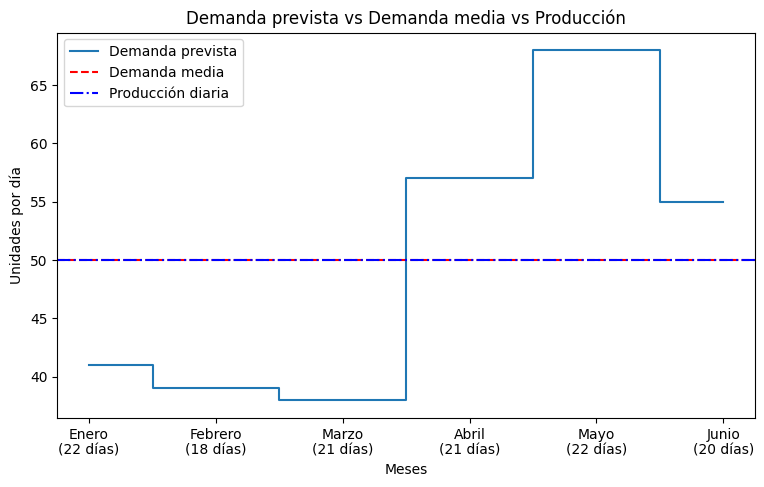

           Mes  Demanda  Días  Demanda por día  Producción por día
0        Enero      900    22             41.0                50.0
1      Febrero      700    18             39.0                50.0
2        Marzo      800    21             38.0                50.0
3        Abril     1200    21             57.0                50.0
4         Mayo     1500    22             68.0                50.0
5        Junio     1100    20             55.0                50.0
Total    Total     6200   124             50.0                50.0


In [10]:
# Datos de prueba
demanda = [900, 700, 800, 1200, 1500, 1100]
dias_mes = [22, 18, 21, 21, 22, 20]

# Caso con 10 empleados y 1.6 horas/unidad
df_plan = ejemplo1_plan_agregado(demanda, dias_mes, empleados=10, horas_por_unidad=1.6)
print(df_plan)


In [4]:
import pandas as pd

def plan1_constante(demanda, dias_mes, empleados, produccion_diaria, costos):
    """
    Plan 1: Mano de obra constante.
    Recibe demanda mensual, días de producción, número de empleados,
    producción diaria por empleado y diccionario de costos.
    Devuelve tabla de producción vs demanda y tabla de costes.
    """
    resultados = []
    inventario = 0
    inventario_total = 0
    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]

    for mes_nombre, d, dias in zip(meses, demanda, dias_mes):
        produccion_mes = produccion_diaria * dias
        valoracion = produccion_mes - d
        inventario = inventario + valoracion
        inventario_total += max(0, inventario)

        valoracion_str = f"+{valoracion}" if valoracion >= 0 else f"{valoracion}"

        resultados.append({
            "Mes": mes_nombre,
            f"Producción a {produccion_diaria} unidades/día": f"{produccion_mes:,}".replace(",", "."),
            "Demanda estimada": f"{d:,}".replace(",", "."),
            "Valoración mensual del inventario": valoracion_str,
            "Inventario final": inventario,
        })

    df = pd.DataFrame(resultados)

    # Fila de totales
    fila_total = pd.DataFrame([{
        "Mes": "Total",
        f"Producción a {produccion_diaria} unidades/día": "",
        "Demanda estimada": "",
        "Valoración mensual del inventario": "",
        "Inventario final": f"{inventario_total:,}".replace(",", "."),
    }])
    df_final = pd.concat([df, fila_total], ignore_index=True)

    # ==========================
    # TABLA DE COSTES
    # ==========================
    coste_inventario = inventario_total * costos["inventario"]
    coste_mano_obra = empleados * costos["salario"] * sum(dias_mes)
    coste_total = coste_inventario + coste_mano_obra

    inv_total_fmt = f"{inventario_total:,}".replace(",", ".")
    dias_totales_fmt = f"{sum(dias_mes):,}".replace(",", ".")
    c_inv_fmt = f"{coste_inventario:,}".replace(",", ".")
    c_mo_fmt = f"{coste_mano_obra:,}".replace(",", ".")
    c_tot_fmt = f"{coste_total:,}".replace(",", ".")

    tabla_costes = pd.DataFrame([
        {
            "Costes": f"Inventario {c_inv_fmt}$",
            "Cálculos": f"(= {inv_total_fmt} unidades almacenadas x {costos['inventario']}$/unidad)",
        },
        {
            "Costes": f"Mano de obra en periodo regular {c_mo_fmt}$",
            "Cálculos": f"(= {empleados} empleados x {costos['salario']}$/día x {dias_totales_fmt} días)",
        },
        {
            "Costes": "Otros costes (horas extras, contratación, despidos, subcontratación) 0$",
            "Cálculos": "",
        },
        {"Costes": f"Coste total {c_tot_fmt}$", "Cálculos": ""},
    ])

    return df_final, tabla_costes


In [12]:
# Datos de prueba
demanda = [900, 700, 800, 1200, 1500, 1100]
dias_mes = [22, 18, 21, 21, 22, 20]
costos = {"inventario": 5, "salario": 40}

# Caso con 10 empleados y producción diaria de 50 unidades
df_produccion, df_costes = plan1_constante(demanda, dias_mes, empleados=7, produccion_diaria=30, costos=costos)

print("\n=== TABLA DE PRODUCCIÓN VS DEMANDA ===")
print(df_produccion.to_string(index=False))

print("\n=== TABLA DE COSTES ===")
print(df_costes.to_string(index=False))



=== TABLA DE PRODUCCIÓN VS DEMANDA ===
    Mes Producción a 30 unidades/día Demanda estimada Valoración mensual del inventario Inventario final
  Enero                          660              900                              -240             -240
Febrero                          540              700                              -160             -400
  Marzo                          630              800                              -170             -570
  Abril                          630            1.200                              -570            -1140
   Mayo                          660            1.500                              -840            -1980
  Junio                          600            1.100                              -500            -2480
  Total                                                                                                0

=== TABLA DE COSTES ===
                                                                 Costes                        